In [8]:
import os
from pathlib import Path
from dotenv import load_dotenv
from IPython.display import Audio, display

import librosa
import librosa.display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from huggingface_hub import snapshot_download, login as hf_login
from datasets import load_dataset

load_dotenv()

HF_TOKEN = os.getenv("HF_TOKEN")
WANDB_API_KEY = os.getenv("WANDB_API_KEY")

In [2]:
ROOT_PATH = Path("../").resolve()
DATA_PATH = ROOT_PATH / "data"

## Dataset

In [ ]:
repo_id = "doof-ferb/fpt_fosd"
local_dir = "../data/fpt_fosd"

downloaded_path = snapshot_download(
    repo_id=repo_id,
    repo_type="dataset",
    local_dir=local_dir,
)

In [3]:
DATASET_PATH = DATA_PATH / "fpt_fosd" / "data"
dataset = load_dataset("parquet", data_dir=DATASET_PATH)
dataset

DatasetDict({
    train: Dataset({
        features: ['audio', 'transcription'],
        num_rows: 25917
    })
})

In [4]:
sample = dataset['train'][0]
sample

{'audio': <datasets.features._torchcodec.AudioDecoder at 0x1167c02c0>,
 'transcription': 'cách để đi'}

In [5]:
audio_data = sample["audio"]["array"]
sampling_rate = sample["audio"]["sampling_rate"]
print("Audio shape:", audio_data.shape)
print("Sampling rate:", sampling_rate)

Audio shape: (62208,)
Sampling rate: 48000


In [12]:
Audio(data=audio_data, rate=sampling_rate)

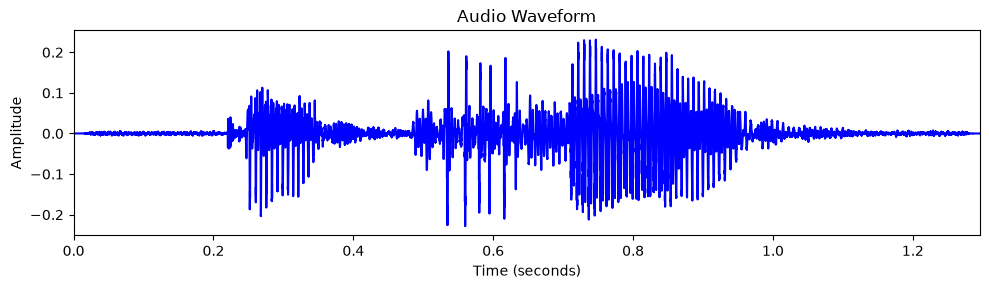

In [14]:
# Create an array of time values (in seconds) for the x-axis
time_axis = np.linspace(0, len(audio_data) / sampling_rate, num=len(audio_data))
plt.figure(figsize=(10, 3))
plt.plot(time_axis, audio_data, color="blue")
plt.title('Audio Waveform')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.xlim([0, time_axis[-1]]) # Ensure the x-axis starts at 0 and ends at the exact length
plt.tight_layout()
plt.show()

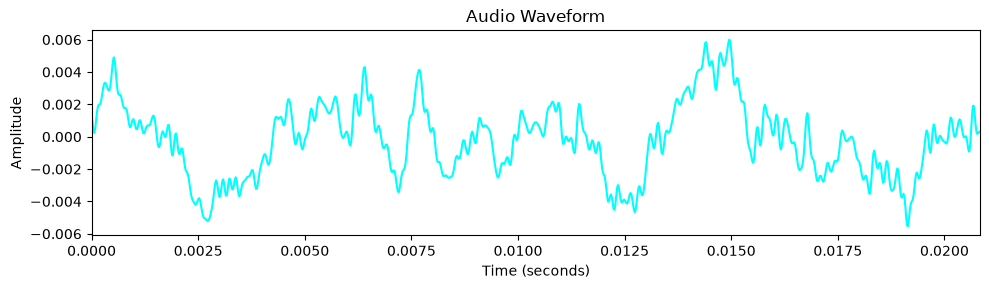

In [21]:
# Create an array of time values (in seconds) for the x-axis
start_time = 2_500
end_time = 3_500
time_axis = np.linspace(0, len(audio_data[start_time: end_time]) / sampling_rate, num=len(audio_data[start_time: end_time]))
plt.figure(figsize=(10, 3))
plt.plot(time_axis, audio_data[start_time: end_time], color="cyan")
plt.title('Audio Waveform')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude')
plt.xlim([0, time_axis[-1]]) # Ensure the x-axis starts at 0 and ends at the exact length
plt.tight_layout()
plt.show()

In [9]:
# 1. Compute the Mel Spectrogram
mel_spectrogram = librosa.feature.melspectrogram(
    y=audio_data, 
    sr=sampling_rate, 
    n_mels=128,        # Number of Mel bands to generate
    n_fft=2048,        # Length of the FFT window
    hop_length=512,    # Number of samples between successive frames
    fmax=8000          # Maximum frequency (optional, often half the SR is good)
)


In [10]:
mel_spectrogram

array([[6.0966478e-08, 1.0056447e-05, 5.5357883e-05, ..., 1.9555129e-03,
        1.8315975e-03, 1.0241462e-04],
       [1.8525972e-07, 4.4469334e-06, 5.1852508e-05, ..., 3.0910459e-03,
        1.4913452e-03, 1.0130708e-04],
       [2.4405526e-07, 1.4135250e-05, 2.5441803e-04, ..., 9.6124917e-04,
        6.1075657e-04, 9.0731679e-05],
       ...,
       [9.7544252e-08, 1.0315480e-06, 4.5622010e-06, ..., 1.3565654e-05,
        1.0747464e-05, 7.9254426e-07],
       [2.6245282e-09, 3.1349953e-07, 4.6276859e-06, ..., 7.2294938e-06,
        4.0376426e-06, 2.2231363e-07],
       [4.2728412e-09, 1.1237010e-07, 4.6374305e-07, ..., 6.0553776e-07,
        4.6723665e-07, 7.8826034e-08]], shape=(128, 122), dtype=float32)

Log-Mel shape: (128, 122)


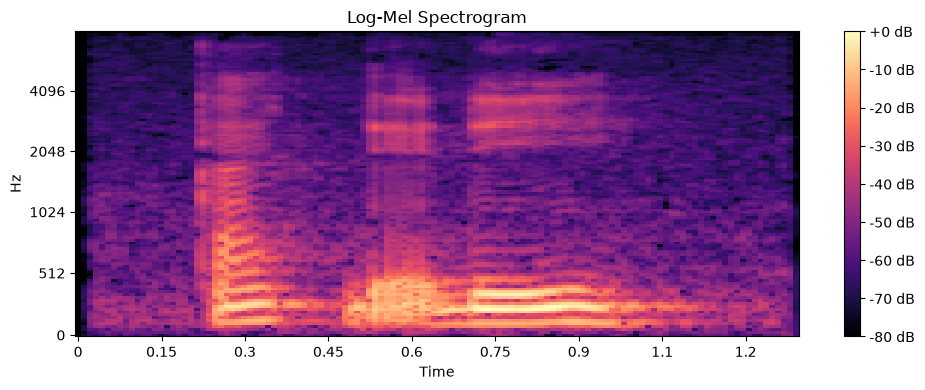

In [11]:
log_mel_spectrogram = librosa.power_to_db(mel_spectrogram, ref=np.max)
print("Log-Mel shape:", log_mel_spectrogram.shape)
# ---------------------------------------------------------
# 3. (Optional) Visualize the Log-Mel Spectrogram
# ---------------------------------------------------------
plt.figure(figsize=(10, 4))
librosa.display.specshow(
    log_mel_spectrogram, 
    sr=sampling_rate, 
    hop_length=512, 
    x_axis='time', 
    y_axis='mel', 
    fmax=8000
)
plt.colorbar(format='%+2.0f dB')
plt.title('Log-Mel Spectrogram')
plt.tight_layout()
plt.show()